# MINI-PROJET VISION PAR ORDINATEUR MODERNE
## Classification d'images, transfer learning et interprétabilité

ESIEE-IT Pontoise — Master 2 IA & Big Data

Le présent notebook suit la structure du sujet : exploration du dataset, puis Partie 1 (pipeline de prétraitement), Partie 2 (feature extraction avec ResNet18), Partie 3 (fine-tuning léger), Partie 4 (évaluation des modèles).


##  Imports et Configuration

In [33]:
import subprocess
import sys

subprocess.check_call([sys.executable, "-m", "pip", "install",
                       "torch", "torchvision", "torchinfo",
                       "matplotlib", "seaborn", "pillow", "numpy",
                       "scikit-learn"])


Defaulting to user installation because normal site-packages is not writeable


0

In [34]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, utils
from PIL import Image
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
torch.manual_seed(42)
np.random.seed(42)

print(" Imports réussis")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")

 Imports réussis
PyTorch version: 2.12.0+cu130
Device: cuda


---
# DATASET — Intel Image Classification

Exploration du dataset : chargement, exemples par classe, statistiques de taille, distribution des classes, vérification de l'équilibre.


##  Configurer le Chemin du Dataset

In [35]:
# Telechargement du dataset Intel Image Classification via curl + API Kaggle.
# Pre-requis : placer le fichier kaggle.json (telecharge depuis Kaggle > Account > Create API Token)
# a la racine du projet, a cote du notebook. Il est ignore par git (cf. .gitignore).
# Le dataset est extrait dans <racine_projet>/intel_image_classification/.

import json as _json
import zipfile

PROJECT_ROOT = Path.cwd().resolve()
DATASET_PATH = Path(os.environ.get(
    "INTEL_IMAGE_DATASET",
    PROJECT_ROOT / "intel_image_classification",
))

train_path = str(DATASET_PATH / "seg_train" / "seg_train")
test_path = str(DATASET_PATH / "seg_test" / "seg_test")

if not (os.path.isdir(train_path) and os.path.isdir(test_path)):
    print(f"Dataset absent dans {DATASET_PATH} : telechargement via curl...")

    # kaggle.json est cherche a la racine du projet, puis dans ~/.kaggle/ en secours.
    candidate_creds = [
        PROJECT_ROOT / "kaggle.json",
        Path.home() / ".kaggle" / "kaggle.json",
    ]
    kaggle_creds_path = next((p for p in candidate_creds if p.is_file()), None)
    if kaggle_creds_path is None:
        raise FileNotFoundError(
            "Credentials Kaggle introuvables. Placez le fichier kaggle.json "
            f"a la racine du projet ({PROJECT_ROOT}) ou dans ~/.kaggle/. "
            "Il se telecharge depuis https://www.kaggle.com/settings > Create API Token."
        )
    creds = _json.loads(kaggle_creds_path.read_text())
    user, key = creds["username"], creds["key"]
    print(f"Credentials Kaggle lus depuis : {kaggle_creds_path}")

    DATASET_PATH.mkdir(parents=True, exist_ok=True)
    zip_path = DATASET_PATH / "intel-image-classification.zip"

    url = "https://www.kaggle.com/api/v1/datasets/download/puneet6060/intel-image-classification"
    rc = subprocess.call([
        "curl", "-L", "--fail", "--retry", "3",
        "-u", f"{user}:{key}",
        "-o", str(zip_path), url,
    ])
    if rc != 0 or not zip_path.is_file():
        raise RuntimeError(f"Echec curl (code={rc}). Verifiez vos credentials Kaggle.")

    print(f"Archive telechargee : {zip_path.stat().st_size / 1e6:.1f} Mo. Extraction...")
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(DATASET_PATH)
    zip_path.unlink()
    print(f"Extraction terminee dans {DATASET_PATH}.")
else:
    print(f"Dataset deja present dans {DATASET_PATH}, telechargement saute.")

CLASSES = ["buildings", "forest", "glacier", "mountain", "sea", "street"]
NUM_CLASSES = len(CLASSES)

print(f"Chemin dataset : {DATASET_PATH}")
print(f"Classes        : {CLASSES}")
print(f"Nombre classes : {NUM_CLASSES}")

if not os.path.isdir(train_path):
    raise FileNotFoundError(f"Dossier train introuvable apres extraction : {train_path}")
if not os.path.isdir(test_path):
    raise FileNotFoundError(f"Dossier test introuvable apres extraction : {test_path}")

print("Dossiers seg_train et seg_test trouves.")


Dataset deja present dans /home/dylan/COURS/M2_COURS/vision_ordi/mini_projet/Mini-projet-vision-par-ordinateur/intel_image_classification, telechargement saute.
Chemin dataset : /home/dylan/COURS/M2_COURS/vision_ordi/mini_projet/Mini-projet-vision-par-ordinateur/intel_image_classification
Classes        : ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Nombre classes : 6
Dossiers seg_train et seg_test trouves.


##  Charger le Dataset Brut

In [36]:
raw_dataset = datasets.ImageFolder(root=train_path)
print(f" Dataset brut chargé: {len(raw_dataset)} images")
print(f" Classes trouvées: {raw_dataset.classes}")

 Dataset brut chargé: 14034 images
 Classes trouvées: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


##  Afficher des Exemples d'Images par Classe

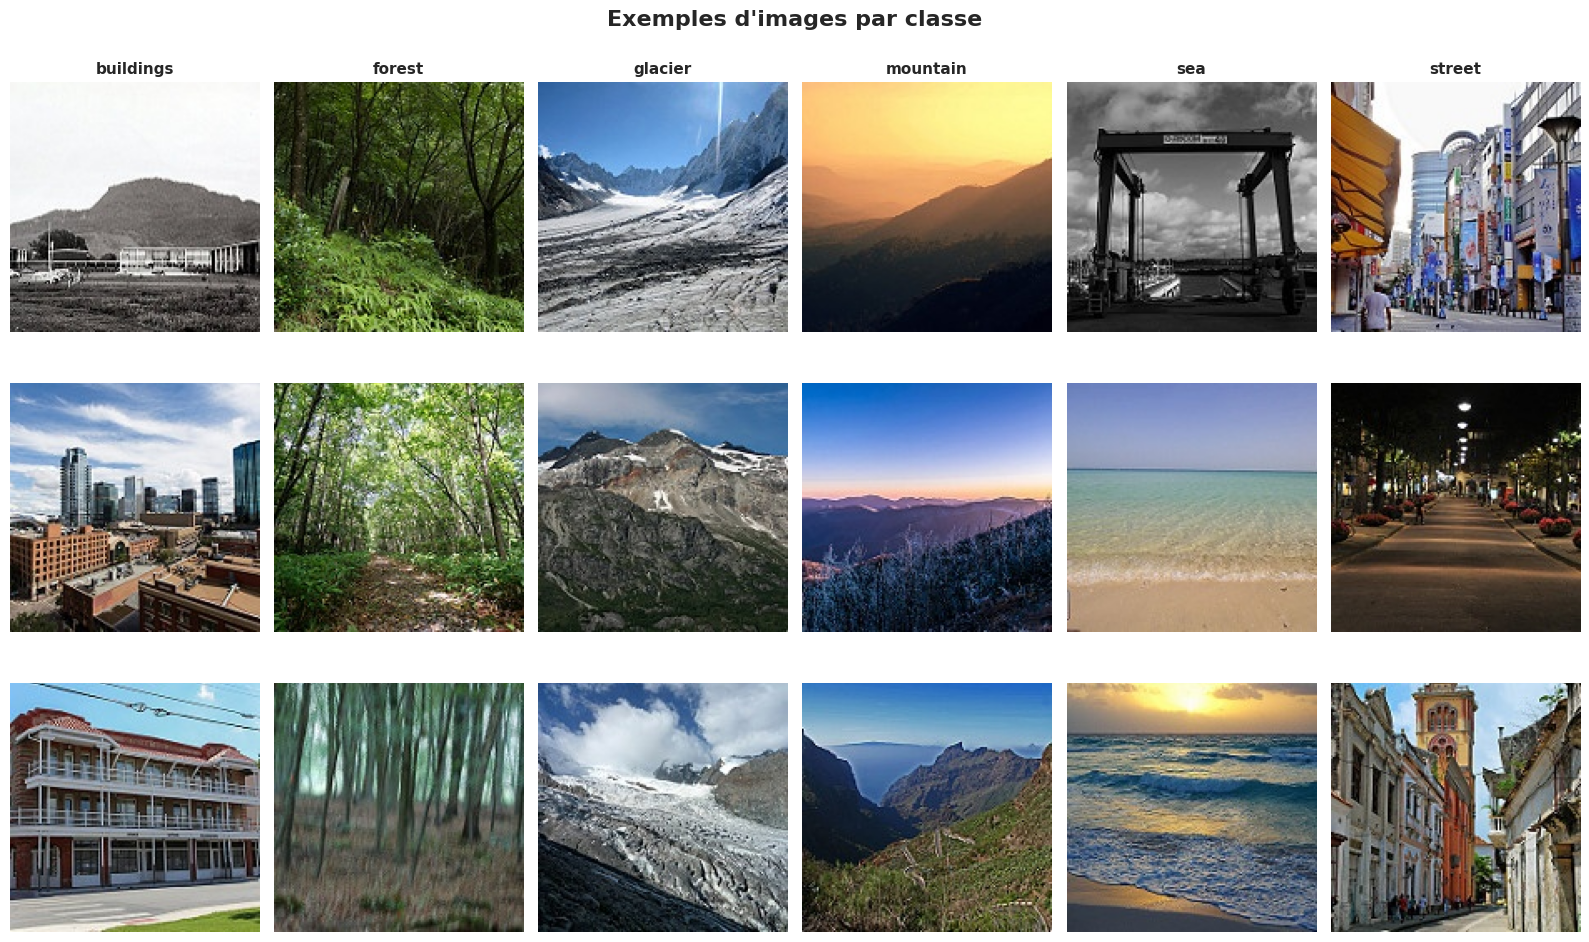

 Figure sauvegardée: 01_exemples_images_par_classe.png


In [37]:
fig, axes = plt.subplots(3, 6, figsize=(16, 10))
fig.suptitle("Exemples d'images par classe", fontsize=16, fontweight='bold')

for class_idx, class_name in enumerate(CLASSES):
    class_path = os.path.join(train_path, class_name)
    images = sorted(os.listdir(class_path))[:3]
    
    for img_idx, img_name in enumerate(images):
        img_path = os.path.join(class_path, img_name)
        img = Image.open(img_path)
        
        ax = axes[img_idx, class_idx]
        ax.imshow(img)
        if img_idx == 0:
            ax.set_title(class_name, fontweight='bold', fontsize=11)
        ax.axis('off')

plt.tight_layout()
plt.savefig('01_exemples_images_par_classe.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Figure sauvegardée: 01_exemples_images_par_classe.png")

##  Vérifier la Taille des Images

In [38]:
image_sizes = []
for class_name in CLASSES:
    class_path = os.path.join(train_path, class_name)
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        try:
            img = Image.open(img_path)
            image_sizes.append(img.size)
        except:
            pass

image_sizes = np.array(image_sizes)
widths = image_sizes[:, 0]
heights = image_sizes[:, 1]

print(" Statistiques des tailles d'images:")
print(f"\n  Largeur (pixels):")
print(f"    Min:     {widths.min():.0f}")
print(f"    Max:     {widths.max():.0f}")
print(f"    Moyenne: {widths.mean():.0f}")
print(f"    Std:     {widths.std():.0f}")

print(f"\n  Hauteur (pixels):")
print(f"    Min:     {heights.min():.0f}")
print(f"    Max:     {heights.max():.0f}")
print(f"    Moyenne: {heights.mean():.0f}")
print(f"    Std:     {heights.std():.0f}")

 Statistiques des tailles d'images:

  Largeur (pixels):
    Min:     150
    Max:     150
    Moyenne: 150
    Std:     0

  Hauteur (pixels):
    Min:     76
    Max:     150
    Moyenne: 150
    Std:     2


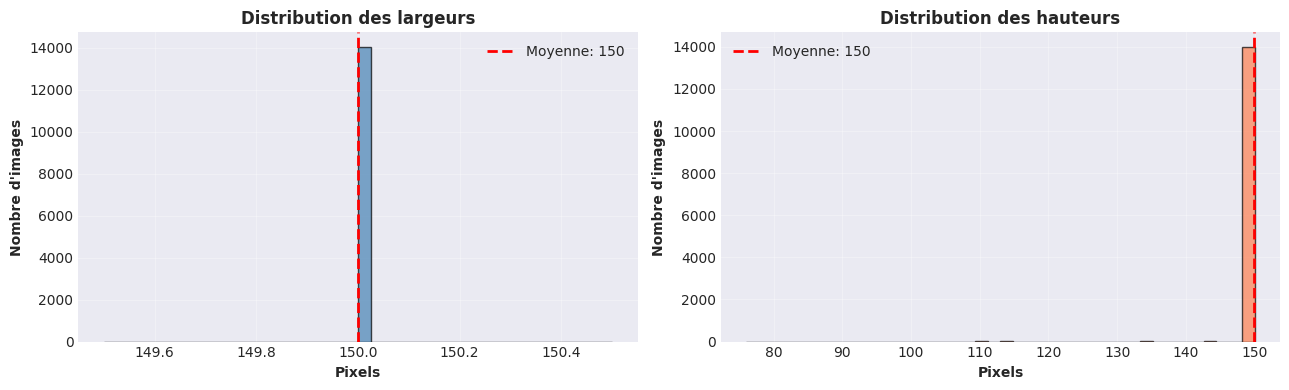

 Figure sauvegardée: 02_distribution_tailles_images.png


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(widths, bins=40, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].axvline(widths.mean(), color='red', linestyle='--', linewidth=2, label=f'Moyenne: {widths.mean():.0f}')
axes[0].set_xlabel('Pixels', fontweight='bold')
axes[0].set_ylabel("Nombre d'images", fontweight='bold')
axes[0].set_title('Distribution des largeurs', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(heights, bins=40, alpha=0.7, color='coral', edgecolor='black')
axes[1].axvline(heights.mean(), color='red', linestyle='--', linewidth=2, label=f'Moyenne: {heights.mean():.0f}')
axes[1].set_xlabel('Pixels', fontweight='bold')
axes[1].set_ylabel("Nombre d'images", fontweight='bold')
axes[1].set_title('Distribution des hauteurs', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('02_distribution_tailles_images.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Figure sauvegardée: 02_distribution_tailles_images.png")

##  Nombre d'Images par Classe

In [40]:
class_counts = {}
for class_name in CLASSES:
    class_path = os.path.join(train_path, class_name)
    count = len([f for f in os.listdir(class_path) if f.endswith(('.jpg', '.png'))])
    class_counts[class_name] = count

print(" Nombre d'images par classe:")
print("-" * 40)
for class_name, count in sorted(class_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"  {class_name:15s}: {count:5d} images")

total_images = sum(class_counts.values())
print("-" * 40)
print(f"  {'TOTAL':15s}: {total_images:5d} images")

 Nombre d'images par classe:
----------------------------------------
  mountain       :  2512 images
  glacier        :  2404 images
  street         :  2382 images
  sea            :  2274 images
  forest         :  2271 images
  buildings      :  2191 images
----------------------------------------
  TOTAL          : 14034 images


##  Distribution des Classes

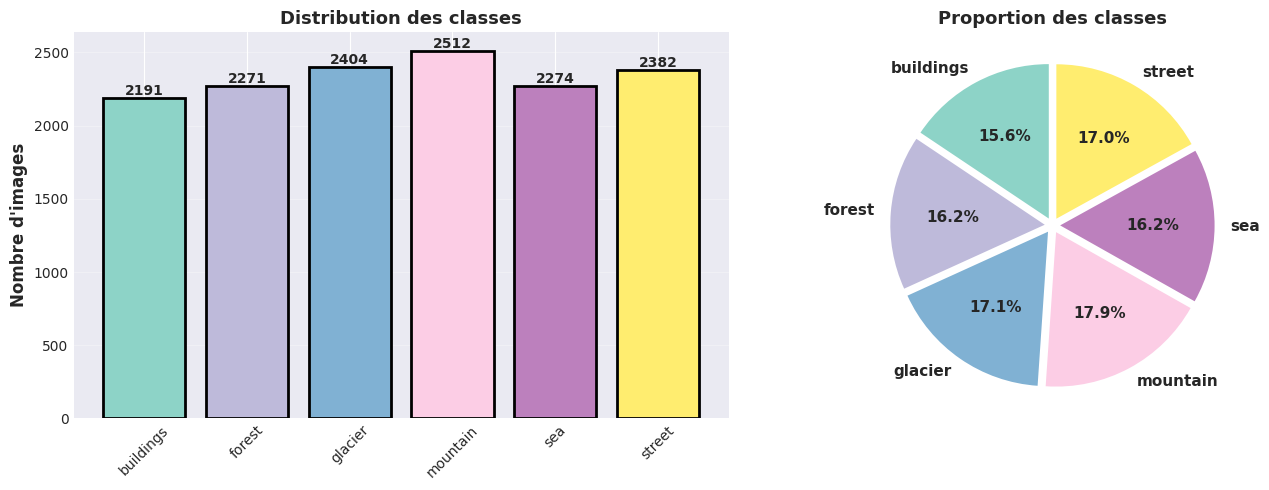

 Figure sauvegardée: 03_distribution_classes.png


In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

classes = list(class_counts.keys())
counts = list(class_counts.values())
colors = plt.cm.Set3(np.linspace(0, 1, len(classes)))

bars = axes[0].bar(classes, counts, color=colors, edgecolor='black', linewidth=2)
axes[0].set_ylabel("Nombre d'images", fontsize=12, fontweight='bold')
axes[0].set_title('Distribution des classes', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].tick_params(axis='x', rotation=45)

for bar, count in zip(bars, counts):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(count)}',
                ha='center', va='bottom', fontweight='bold')

axes[1].pie(counts, labels=classes, autopct='%1.1f%%', colors=colors,
            startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'},
            explode=[0.05] * len(classes))
axes[1].set_title('Proportion des classes', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('03_distribution_classes.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Figure sauvegardée: 03_distribution_classes.png")

##  Équilibre du Dataset

In [42]:
class_percentages = {cls: (count / total_images) * 100 for cls, count in class_counts.items()}
min_pct = min(class_percentages.values())
max_pct = max(class_percentages.values())
imbalance_ratio = max_pct / min_pct

print("  Analyse de l'équilibre du dataset:")
print("-" * 50)
print(f"\nProportions par classe:")
for cls in sorted(class_percentages.keys()):
    pct = class_percentages[cls]
    bar_len = int(pct / 2)
    bar = "#" * bar_len
    print(f"  {cls:15s}: {pct:5.2f}% {bar}")

print(f"\nRatio de déséquilibre (max/min): {imbalance_ratio:.2f}")

if imbalance_ratio < 1.2:
    print(" Dataset TRÈS bien équilibré!")
elif imbalance_ratio < 2.0:
    print(" Dataset légèrement déséquilibré (acceptable)")
elif imbalance_ratio < 3.0:
    print("  Dataset modérément déséquilibré")
else:
    print("  Dataset fortement déséquilibré")

  Analyse de l'équilibre du dataset:
--------------------------------------------------

Proportions par classe:
  buildings      : 15.61% #######
  forest         : 16.18% ########
  glacier        : 17.13% ########
  mountain       : 17.90% ########
  sea            : 16.20% ########
  street         : 16.97% ########

Ratio de déséquilibre (max/min): 1.15
 Dataset TRÈS bien équilibré!


---
# PARTIE 1 — Pipeline de prétraitement

Conversion en tenseurs, redimensionnement, normalisation ImageNet, séparation train/val/test, DataLoaders, et stratégie de data augmentation.


##  Définir les Transformations

In [43]:
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0  

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

print("  Paramètres de configuration:")
print(f"  IMG_SIZE:     {IMG_SIZE}×{IMG_SIZE} pixels")
print(f"  BATCH_SIZE:   {BATCH_SIZE}")
print(f"  NUM_WORKERS:  {NUM_WORKERS}")

train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),  
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.RandomCrop(224, padding=8), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print(f" Transformations TRAIN (avec augmentation):")
print(f"   RandomHorizontalFlip (probabilité: 50%)")
print(f"   RandomRotation (±15 degrés)")
print(f"   RandomCrop ({IMG_SIZE}×{IMG_SIZE}, padding=8)")
print(f"   Resize vers {IMG_SIZE}×{IMG_SIZE}")
print(f"   ToTensor (valeurs [0, 1])")
print(f"   Normalize (normalisation ImageNet)")

print(f" Transformations VAL/TEST (sans augmentation):")
print(f"   Resize vers {IMG_SIZE}×{IMG_SIZE}")
print(f"   ToTensor (valeurs [0, 1])")
print(f"   Normalize (normalisation ImageNet)")

  Paramètres de configuration:
  IMG_SIZE:     224×224 pixels
  BATCH_SIZE:   32
  NUM_WORKERS:  0
 Transformations TRAIN (avec augmentation):
   RandomHorizontalFlip (probabilité: 50%)
   RandomRotation (±15 degrés)
   RandomCrop (224×224, padding=8)
   Resize vers 224×224
   ToTensor (valeurs [0, 1])
   Normalize (normalisation ImageNet)
 Transformations VAL/TEST (sans augmentation):
   Resize vers 224×224
   ToTensor (valeurs [0, 1])
   Normalize (normalisation ImageNet)


##  Charger le Dataset avec Transformations

In [44]:
train_dataset = datasets.ImageFolder(root=train_path, transform=train_transforms)
test_dataset = datasets.ImageFolder(root=test_path, transform=val_test_transforms)

print(f" Dataset TRAIN chargé: {len(train_dataset)} images")
print(f" Dataset TEST chargé:  {len(test_dataset)} images")

 Dataset TRAIN chargé: 14034 images
 Dataset TEST chargé:  3000 images


##  Créer les Ensembles Train/Validation

In [45]:
TRAIN_SPLIT = 0.8
train_size = int(len(train_dataset) * TRAIN_SPLIT)
val_size = len(train_dataset) - train_size

train_set, val_set = random_split(
    train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print(f" Répartition des données:")
print(f"  Train: {len(train_set)} images ({TRAIN_SPLIT*100:.0f}%)")
print(f"  Val:   {len(val_set)} images ({(1-TRAIN_SPLIT)*100:.0f}%)")
print(f"  Test:  {len(test_dataset)} images (ensemble de test indépendant)")
print(f"  ")
print(f"  Total: {len(train_set) + len(val_set) + len(test_dataset)} images")

 Répartition des données:
  Train: 11227 images (80%)
  Val:   2807 images (20%)
  Test:  3000 images (ensemble de test indépendant)
  
  Total: 17034 images


##  Créer les DataLoaders

In [46]:
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)

print(f" DataLoaders créés:")
print(f"  train_loader: {len(train_loader)} batches de {BATCH_SIZE} images")
print(f"  val_loader:   {len(val_loader)} batches de {BATCH_SIZE} images")
print(f"  test_loader:  {len(test_loader)} batches de {BATCH_SIZE} images")

 DataLoaders créés:
  train_loader: 351 batches de 32 images
  val_loader:   88 batches de 32 images
  test_loader:  94 batches de 32 images


##  Vérifier les Dimensions des Tenseurs

In [47]:
batch_images, batch_labels = next(iter(train_loader))

print(f" Analyse des tenseurs:")
print(f"\nBatch d'entraînement:")
print(f"  Shape des images:  {tuple(batch_images.shape)}")
print(f"    → B (Batch):     {batch_images.shape[0]} images")
print(f"    → C (Channels):  {batch_images.shape[1]} (RGB)")
print(f"    → H (Height):    {batch_images.shape[2]} pixels")
print(f"    → W (Width):     {batch_images.shape[3]} pixels")
print(f"\n  Shape des labels: {tuple(batch_labels.shape)}")
print(f"  Type des images:   {batch_images.dtype}")
print(f"  Type des labels:   {batch_labels.dtype}")

print(f" Rôle des dimensions C, H, W:")
print(f"  C (Channels = 3):")
print(f"    → Représente les 3 canaux RGB (Red, Green, Blue)")
print(f"    → Chaque canal contient l'intensité de cette couleur")
print(f"\n  H (Height = {IMG_SIZE}):")
print(f"    → Nombre de pixels en hauteur")
print(f"\n  W (Width = {IMG_SIZE}):")
print(f"    → Nombre de pixels en largeur")

 Analyse des tenseurs:

Batch d'entraînement:
  Shape des images:  (32, 3, 224, 224)
    → B (Batch):     32 images
    → C (Channels):  3 (RGB)
    → H (Height):    224 pixels
    → W (Width):     224 pixels

  Shape des labels: (32,)
  Type des images:   torch.float32
  Type des labels:   torch.int64
 Rôle des dimensions C, H, W:
  C (Channels = 3):
    → Représente les 3 canaux RGB (Red, Green, Blue)
    → Chaque canal contient l'intensité de cette couleur

  H (Height = 224):
    → Nombre de pixels en hauteur

  W (Width = 224):
    → Nombre de pixels en largeur


##  Visualiser Avant/Après Transformation

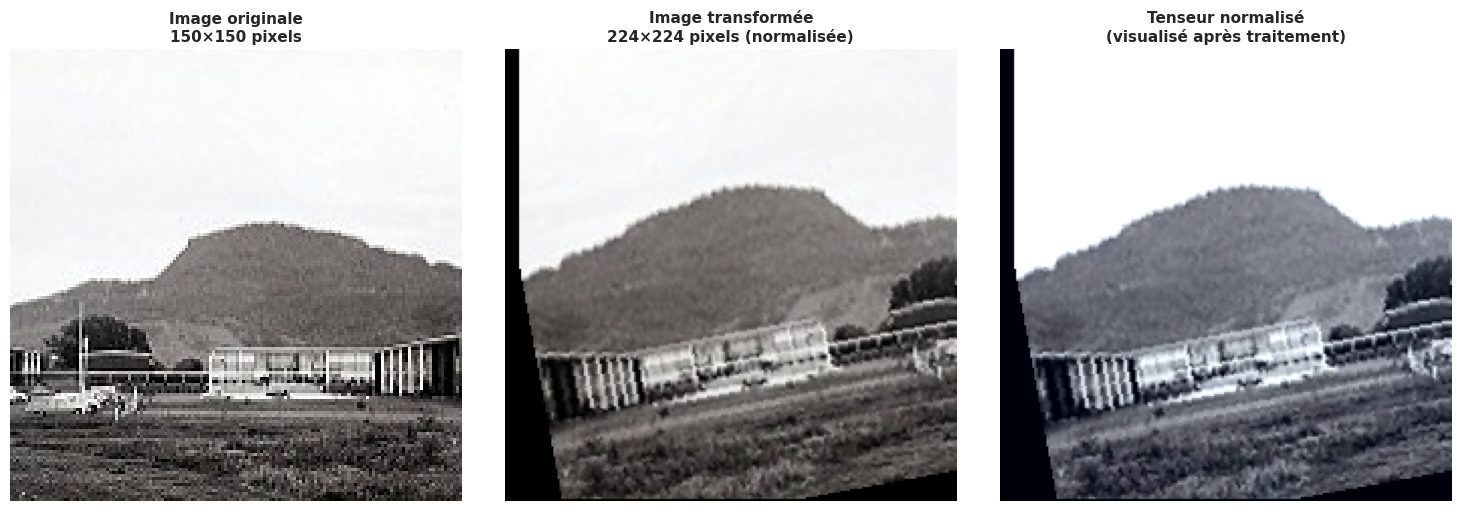

 Figure sauvegardée: 04_avant_apres_transformation.png


In [48]:
sample_class_path = os.path.join(train_path, "buildings")
sample_img_name = sorted(os.listdir(sample_class_path))[0]
sample_img_path = os.path.join(sample_class_path, sample_img_name)

img_original = Image.open(sample_img_path)
img_transformed = train_transforms(img_original)

img_denorm = img_transformed.clone()
for i, (mean, std) in enumerate(zip(IMAGENET_MEAN, IMAGENET_STD)):
    img_denorm[i] = img_denorm[i] * std + mean

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_original)
axes[0].set_title(f"Image originale\n{img_original.size[0]}×{img_original.size[1]} pixels", 
                  fontweight='bold', fontsize=11)
axes[0].axis('off')

img_to_display = torch.clamp(img_denorm, 0, 1).permute(1, 2, 0).numpy()
axes[1].imshow(img_to_display)
axes[1].set_title(f"Image transformée\n{IMG_SIZE}×{IMG_SIZE} pixels (normalisée)", 
                  fontweight='bold', fontsize=11)
axes[1].axis('off')

img_norm_display = (torch.clamp(img_transformed, -2, 2) / 4 + 0.5).permute(1, 2, 0).numpy()
axes[2].imshow(np.clip(img_norm_display, 0, 1))
axes[2].set_title("Tenseur normalisé\n(visualisé après traitement)", 
                  fontweight='bold', fontsize=11)
axes[2].axis('off')

plt.tight_layout()
plt.savefig('04_avant_apres_transformation.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Figure sauvegardée: 04_avant_apres_transformation.png")

##  Exemples d'Augmentation de Données

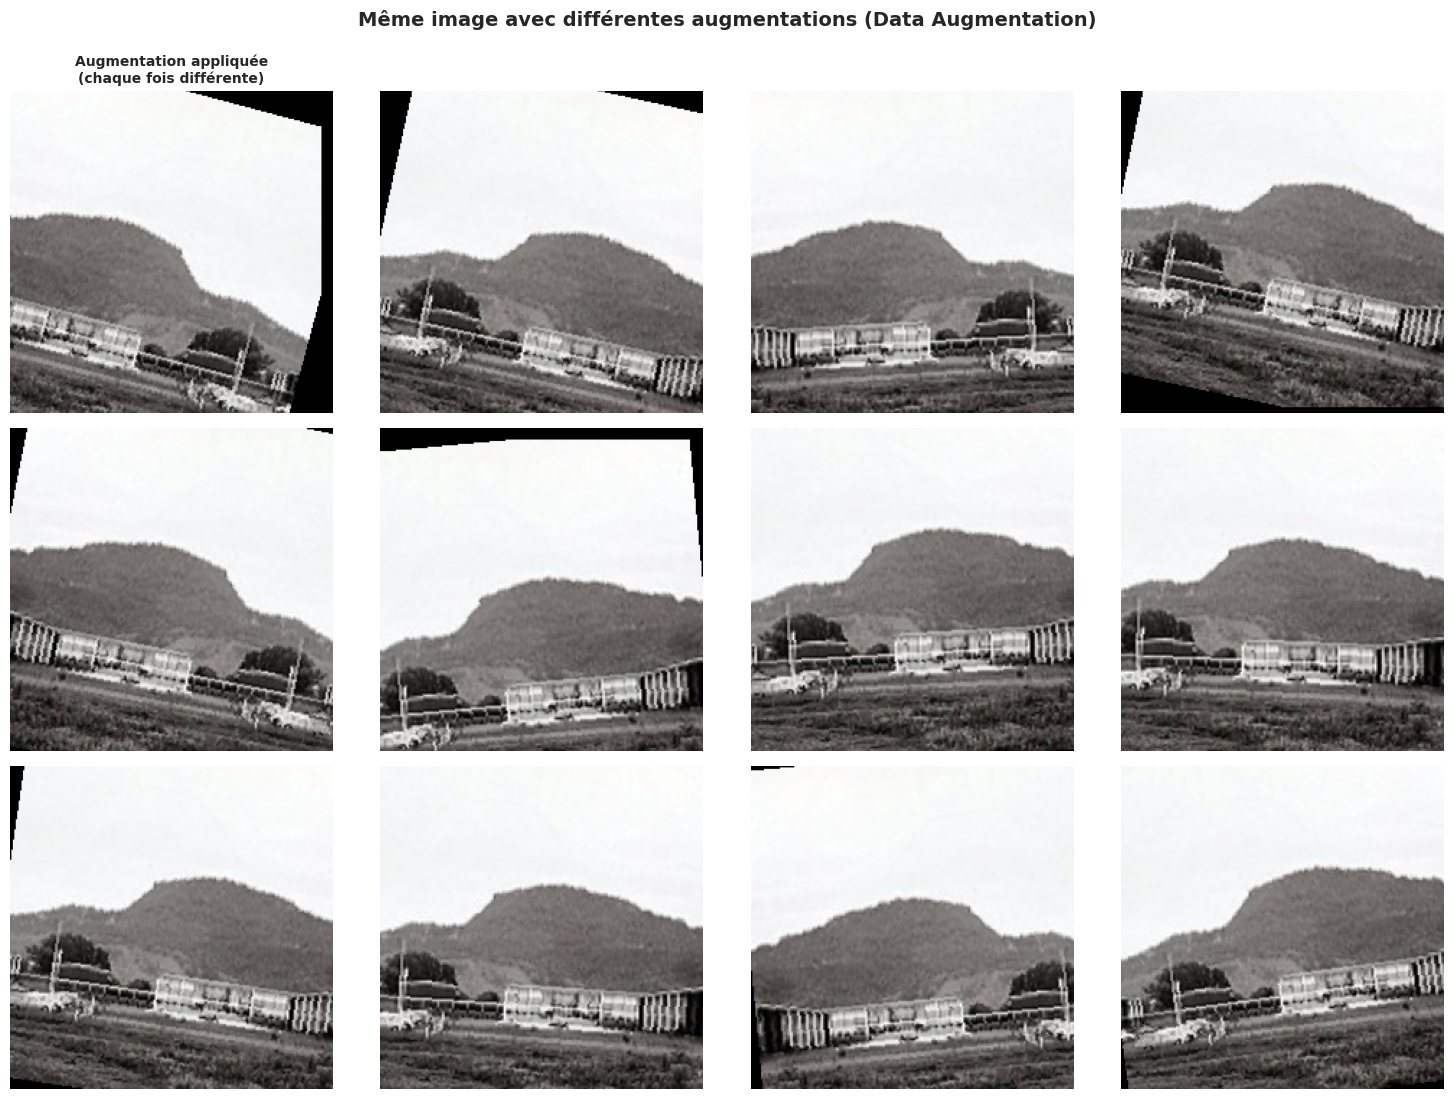

 Figure sauvegardée: 05_exemples_augmentation.png


In [49]:
fig, axes = plt.subplots(3, 4, figsize=(15, 11))
fig.suptitle("Même image avec différentes augmentations (Data Augmentation)", 
             fontsize=14, fontweight='bold', y=0.995)

img_for_aug = Image.open(sample_img_path)

for row in range(3):
    for col in range(4):
        img_aug = train_transforms(img_for_aug)
        
        img_aug_display = img_aug.clone()
        for i, (mean, std) in enumerate(zip(IMAGENET_MEAN, IMAGENET_STD)):
            img_aug_display[i] = img_aug_display[i] * std + mean
        img_aug_display = torch.clamp(img_aug_display, 0, 1).permute(1, 2, 0).numpy()
        
        ax = axes[row, col]
        ax.imshow(img_aug_display)
        ax.axis('off')
        
        if row == 0 and col == 0:
            ax.set_title("Augmentation appliquée\n(chaque fois différente)", 
                         fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('05_exemples_augmentation.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Figure sauvegardée: 05_exemples_augmentation.png")

---
# PARTIE 2 — Feature extraction avec ResNet18

On utilise ResNet18 pré-entraîné sur ImageNet comme extracteur de caractéristiques figé. Seule la couche de classification finale (fc) est ré-entraînée pour les 6 classes du dataset Intel.


## Imports spécifiques (modèle et entraînement)


In [50]:
import time
import copy
from collections import defaultdict

import torch.optim as optim
from torchvision import models

try:
    from torchinfo import summary as torchinfo_summary
    HAS_TORCHINFO = True
except ImportError:
    HAS_TORCHINFO = False
    print("torchinfo non installe : utilisation d'un resume manuel.")

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device utilise : {DEVICE}")


Device utilise : cuda


## Chargement de ResNet18 pré-entraîné et adaptation de la couche finale

ResNet18 a été pré-entraîné sur ImageNet (1000 classes). On remplace la dernière couche `fc` (`Linear(512, 1000)`) par une nouvelle `Linear(512, 6)` qui correspond au nombre de classes du dataset Intel.


In [51]:
def build_resnet18_feature_extractor(num_classes: int = NUM_CLASSES) -> nn.Module:
    """ResNet18 ImageNet, backbone gele, fc remplacee par num_classes sorties."""
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    # Geler tous les parametres du backbone
    for param in model.parameters():
        param.requires_grad = False
    # Remplacer la tete de classification
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model

model_fe = build_resnet18_feature_extractor().to(DEVICE)
print("ResNet18 charge et adapte aux 6 classes Intel Image Classification.")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/dylan/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 105MB/s] 


ResNet18 charge et adapte aux 6 classes Intel Image Classification.


## Affichage de l'architecture et comptage des paramètres


In [52]:
def count_params(model: nn.Module) -> tuple[int, int]:
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

total_params, trainable_params = count_params(model_fe)
print(f"Parametres totaux       : {total_params:,}")
print(f"Parametres entrainables : {trainable_params:,}")
print(f"Proportion entrainable  : {100 * trainable_params / total_params:.3f}%")

if HAS_TORCHINFO:
    torchinfo_summary(model_fe, input_size=(1, 3, IMG_SIZE, IMG_SIZE),
                     col_names=("input_size", "output_size", "num_params", "trainable"),
                     depth=2)
else:
    print(model_fe)


Parametres totaux       : 11,179,590
Parametres entrainables : 3,078
Proportion entrainable  : 0.028%


## Boucle d'entraînement réutilisable

La même fonction sera utilisée pour entraîner le modèle en feature extraction puis le modèle fine-tuné. Elle conserve à chaque époque la loss et l'accuracy sur train et validation, et garde une copie des poids correspondant à la meilleure accuracy de validation.


In [53]:
def train_model(model: nn.Module,
                train_loader: DataLoader,
                val_loader: DataLoader,
                criterion: nn.Module,
                optimizer: torch.optim.Optimizer,
                num_epochs: int,
                device: torch.device = DEVICE) -> tuple[nn.Module, dict, float]:
    """Entrainement classique. Retourne (modele_meilleurs_poids, historique, duree_secondes)."""
    history = defaultdict(list)
    best_acc = 0.0
    best_state = copy.deepcopy(model.state_dict())
    t0 = time.time()

    for epoch in range(1, num_epochs + 1):
        # ----- TRAIN -----
        model.train()
        running_loss, running_correct, running_total = 0.0, 0, 0
        for images, labels in train_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            running_correct += (outputs.argmax(1) == labels).sum().item()
            running_total += images.size(0)
        train_loss = running_loss / running_total
        train_acc = running_correct / running_total

        # ----- VALIDATION -----
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()
                val_total += images.size(0)
        val_loss = val_loss / val_total
        val_acc = val_correct / val_total

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch:2d}/{num_epochs} | "
              f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
              f"val loss {val_loss:.4f} acc {val_acc:.4f}")

        if val_acc > best_acc:
            best_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

    duration = time.time() - t0
    print(f"Entrainement termine en {duration:.1f}s — meilleure val_acc = {best_acc:.4f}")
    model.load_state_dict(best_state)
    return model, dict(history), duration


## Entraînement de la tête de classification (backbone gelé)

Seuls les paramètres de `model.fc` sont passés à l'optimiseur. Le backbone reste figé.


In [54]:
NUM_EPOCHS_FE = 8
LR_FE = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer_fe = optim.Adam(
    [p for p in model_fe.parameters() if p.requires_grad],
    lr=LR_FE,
)

print(f"Optimiseur Adam, lr={LR_FE}, epochs={NUM_EPOCHS_FE}")
model_fe, history_fe, duration_fe = train_model(
    model_fe, train_loader, val_loader, criterion, optimizer_fe,
    num_epochs=NUM_EPOCHS_FE,
)


Optimiseur Adam, lr=0.001, epochs=8
Epoch  1/8 | train loss 0.6339 acc 0.7871 | val loss 0.3863 acc 0.8625
Epoch  2/8 | train loss 0.3804 acc 0.8667 | val loss 0.3422 acc 0.8810
Epoch  3/8 | train loss 0.3549 acc 0.8706 | val loss 0.3256 acc 0.8835
Epoch  4/8 | train loss 0.3459 acc 0.8735 | val loss 0.3371 acc 0.8721
Epoch  5/8 | train loss 0.3284 acc 0.8794 | val loss 0.3330 acc 0.8803
Epoch  6/8 | train loss 0.3385 acc 0.8796 | val loss 0.3216 acc 0.8831
Epoch  7/8 | train loss 0.3239 acc 0.8828 | val loss 0.3069 acc 0.8921
Epoch  8/8 | train loss 0.3231 acc 0.8809 | val loss 0.3161 acc 0.8853
Entrainement termine en 307.6s — meilleure val_acc = 0.8921


## Courbes de loss et d'accuracy — Feature extraction


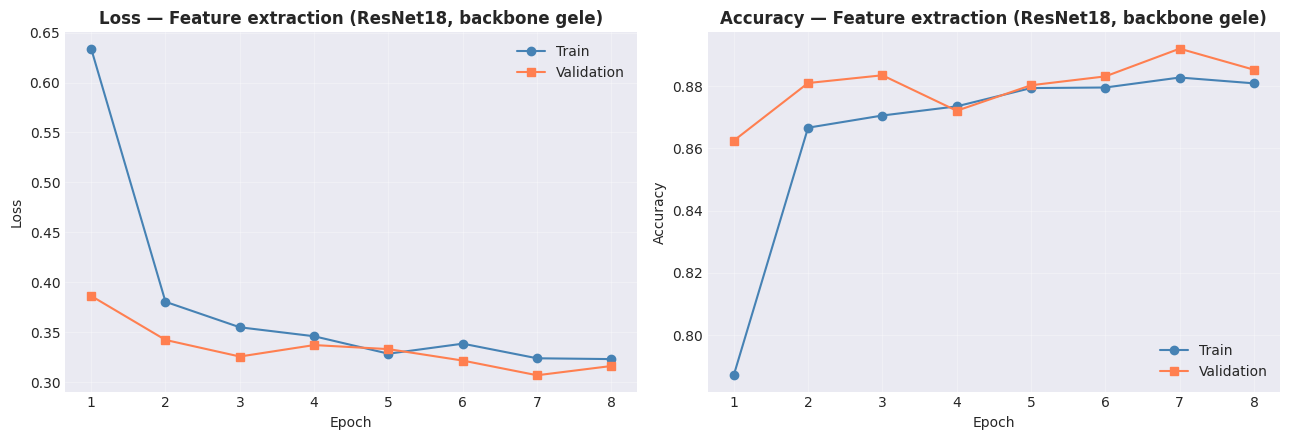

In [55]:
def plot_training_history(history: dict, title: str, savepath: str | None = None) -> None:
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].plot(epochs, history['train_loss'], 'o-', label='Train', color='steelblue')
    axes[0].plot(epochs, history['val_loss'], 's-', label='Validation', color='coral')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f'Loss — {title}', fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, history['train_acc'], 'o-', label='Train', color='steelblue')
    axes[1].plot(epochs, history['val_acc'], 's-', label='Validation', color='coral')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'Accuracy — {title}', fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=150, bbox_inches='tight')
    plt.show()

plot_training_history(history_fe, 'Feature extraction (ResNet18, backbone gele)',
                      savepath='06_courbes_feature_extraction.png')


---
# PARTIE 3 — Fine-tuning léger

On dégèle uniquement le dernier bloc résiduel `layer4` ainsi que la nouvelle couche `fc`. Le reste du backbone reste figé. On utilise un learning rate très faible (`1e-4`) pour éviter de détruire les représentations apprises sur ImageNet. L'entraînement reste court (peu d'époques) pour limiter le risque d'overfitting sur les ~11k images de train.


## Construction du modèle fine-tuné


In [56]:
def build_resnet18_finetune(num_classes: int = NUM_CLASSES) -> nn.Module:
    """ResNet18 ImageNet : seuls layer4 + fc sont entrainables."""
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    for param in model.parameters():
        param.requires_grad = False
    # Degeler layer4 (dernier bloc residuel)
    for param in model.layer4.parameters():
        param.requires_grad = True
    # Nouvelle tete (entrainable par defaut)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model

model_ft = build_resnet18_finetune().to(DEVICE)
total_ft, trainable_ft = count_params(model_ft)
print(f"Parametres totaux       : {total_ft:,}")
print(f"Parametres entrainables : {trainable_ft:,}")
print(f"Proportion entrainable  : {100 * trainable_ft / total_ft:.2f}%")


Parametres totaux       : 11,179,590
Parametres entrainables : 8,396,806
Proportion entrainable  : 75.11%


## Entraînement fine-tuning

Petit learning rate (`1e-4`) et `weight_decay` léger pour régulariser légèrement les couches dégelées.


In [57]:
NUM_EPOCHS_FT = 5
LR_FT = 1e-4

optimizer_ft = optim.Adam(
    [p for p in model_ft.parameters() if p.requires_grad],
    lr=LR_FT,
    weight_decay=1e-4,
)

print(f"Optimiseur Adam, lr={LR_FT}, weight_decay=1e-4, epochs={NUM_EPOCHS_FT}")
model_ft, history_ft, duration_ft = train_model(
    model_ft, train_loader, val_loader, criterion, optimizer_ft,
    num_epochs=NUM_EPOCHS_FT,
)


Optimiseur Adam, lr=0.0001, weight_decay=1e-4, epochs=5
Epoch  1/5 | train loss 0.3464 acc 0.8773 | val loss 0.2568 acc 0.9106
Epoch  2/5 | train loss 0.2188 acc 0.9231 | val loss 0.2108 acc 0.9241
Epoch  3/5 | train loss 0.1792 acc 0.9344 | val loss 0.2134 acc 0.9216
Epoch  4/5 | train loss 0.1493 acc 0.9464 | val loss 0.2010 acc 0.9344
Epoch  5/5 | train loss 0.1257 acc 0.9548 | val loss 0.2245 acc 0.9220
Entrainement termine en 196.8s — meilleure val_acc = 0.9344


## Courbes de loss et d'accuracy — Fine-tuning


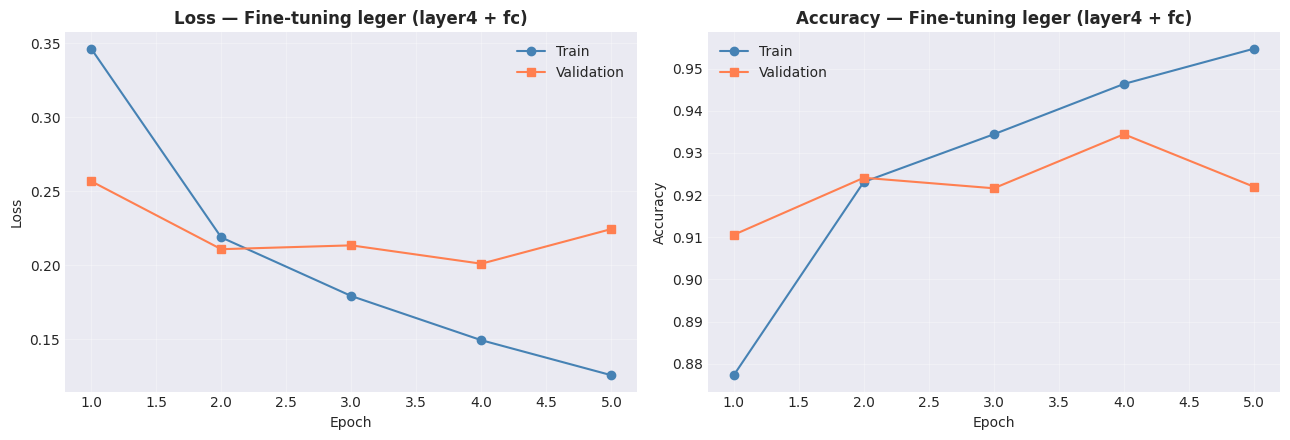

In [58]:
plot_training_history(history_ft, 'Fine-tuning leger (layer4 + fc)',
                      savepath='07_courbes_fine_tuning.png')


## Comparaison directe des deux entraînements

Pour comparer visuellement : courbes de validation superposées + tableau récapitulatif (temps, nombre de paramètres entraînables, meilleure accuracy de validation).


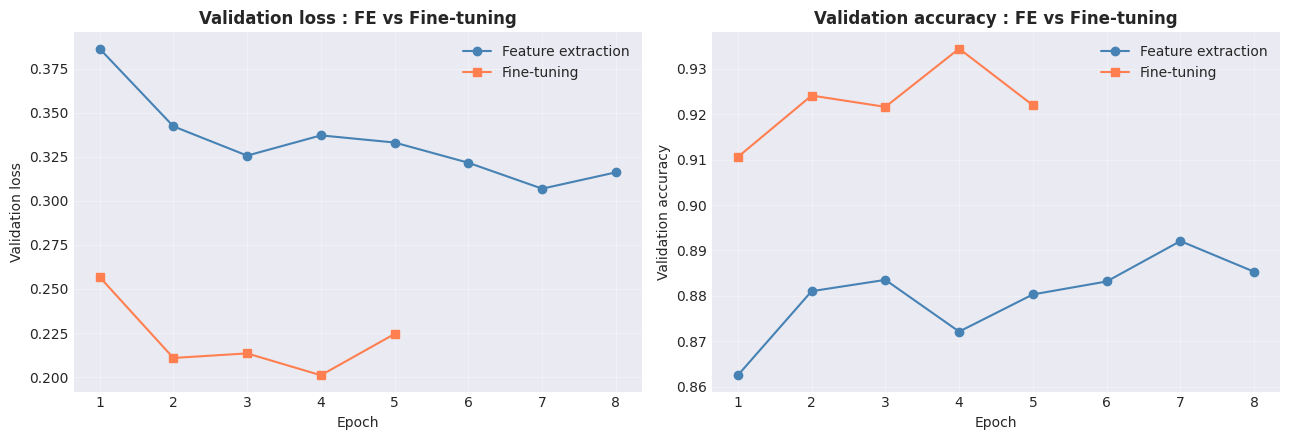


Tableau recapitulatif :
----------------------------------------------------------------------
Approche                  Params entrainables   Temps (s)  Best val acc
----------------------------------------------------------------------
Feature extraction                      3,078       307.6        0.8921
Fine-tuning leger                   8,396,806       196.8        0.9344
----------------------------------------------------------------------


In [59]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(range(1, len(history_fe['val_loss']) + 1), history_fe['val_loss'],
             'o-', label='Feature extraction', color='steelblue')
axes[0].plot(range(1, len(history_ft['val_loss']) + 1), history_ft['val_loss'],
             's-', label='Fine-tuning', color='coral')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation loss')
axes[0].set_title('Validation loss : FE vs Fine-tuning', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, len(history_fe['val_acc']) + 1), history_fe['val_acc'],
             'o-', label='Feature extraction', color='steelblue')
axes[1].plot(range(1, len(history_ft['val_acc']) + 1), history_ft['val_acc'],
             's-', label='Fine-tuning', color='coral')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation accuracy')
axes[1].set_title('Validation accuracy : FE vs Fine-tuning', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('08_comparaison_fe_vs_ft.png', dpi=150, bbox_inches='tight')
plt.show()

best_fe = max(history_fe['val_acc'])
best_ft = max(history_ft['val_acc'])
print()
print("Tableau recapitulatif :")
print("-" * 70)
print(f"{'Approche':<25}{'Params entrainables':>20}{'Temps (s)':>12}{'Best val acc':>14}")
print("-" * 70)
print(f"{'Feature extraction':<25}{trainable_params:>20,}{duration_fe:>12.1f}{best_fe:>14.4f}")
print(f"{'Fine-tuning leger':<25}{trainable_ft:>20,}{duration_ft:>12.1f}{best_ft:>14.4f}")
print("-" * 70)


---
# PARTIE 4 — Évaluation des modèles

Évaluation des deux modèles entraînés sur le **test set** indépendant : accuracy globale, precision/recall/F1 par classe, matrice de confusion. On compare ensuite les deux approches pour identifier les classes les mieux reconnues et les plus difficiles.


## Outils d'évaluation


In [60]:
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_recall_fscore_support,
)

CLASS_NAMES = train_dataset.classes  # ordre alphabetique determine par ImageFolder
print(f"Ordre des classes (ImageFolder) : {CLASS_NAMES}")

@torch.no_grad()
def predict_dataset(model: nn.Module, loader: DataLoader,
                    device: torch.device = DEVICE) -> tuple[np.ndarray, np.ndarray]:
    """Retourne (y_true, y_pred) pour l'ensemble du loader."""
    model.eval()
    y_true, y_pred = [], []
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        outputs = model(images)
        preds = outputs.argmax(1).cpu().numpy()
        y_true.append(labels.numpy())
        y_pred.append(preds)
    return np.concatenate(y_true), np.concatenate(y_pred)


Ordre des classes (ImageFolder) : ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


## Prédictions sur le test set


In [61]:
y_true_fe, y_pred_fe = predict_dataset(model_fe, test_loader)
y_true_ft, y_pred_ft = predict_dataset(model_ft, test_loader)
# y_true_fe == y_true_ft (meme test_loader, meme ordre), on n'en garde qu'un
y_true = y_true_fe
print(f"Predictions calculees sur {len(y_true)} images de test.")


Predictions calculees sur 3000 images de test.


## Accuracy globale


In [62]:
acc_fe = accuracy_score(y_true, y_pred_fe)
acc_ft = accuracy_score(y_true, y_pred_ft)
print(f"Accuracy test — Feature extraction : {acc_fe:.4f}")
print(f"Accuracy test — Fine-tuning leger  : {acc_ft:.4f}")
print(f"Difference absolue                : {acc_ft - acc_fe:+.4f}")


Accuracy test — Feature extraction : 0.8907
Accuracy test — Fine-tuning leger  : 0.9333
Difference absolue                : +0.0427


## Precision, recall et F1 par classe


In [63]:
print("=== Feature extraction ===")
print(classification_report(y_true, y_pred_fe, target_names=CLASS_NAMES, digits=4))

print("=== Fine-tuning leger ===")
print(classification_report(y_true, y_pred_ft, target_names=CLASS_NAMES, digits=4))


=== Feature extraction ===
              precision    recall  f1-score   support

   buildings     0.8979    0.8856    0.8917       437
      forest     0.9873    0.9873    0.9873       474
     glacier     0.9353    0.6799    0.7874       553
    mountain     0.7481    0.9333    0.8305       525
         sea     0.9319    0.9667    0.9490       510
      street     0.8998    0.9142    0.9069       501

    accuracy                         0.8907      3000
   macro avg     0.9001    0.8945    0.8922      3000
weighted avg     0.8988    0.8907    0.8892      3000

=== Fine-tuning leger ===
              precision    recall  f1-score   support

   buildings     0.9316    0.9039    0.9175       437
      forest     0.9916    0.9979    0.9947       474
     glacier     0.9071    0.8825    0.8946       553
    mountain     0.8954    0.8971    0.8963       525
         sea     0.9559    0.9784    0.9671       510
      street     0.9240    0.9461    0.9349       501

    accuracy            

## Matrice de confusion — Feature extraction


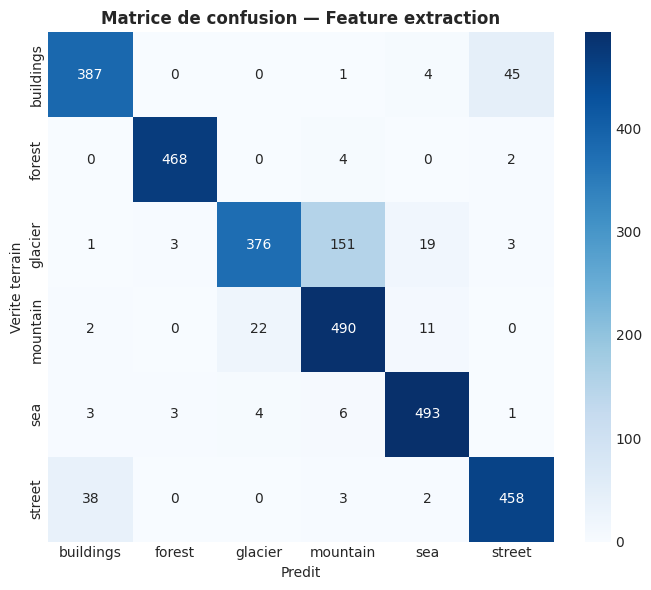

In [64]:
def plot_confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray,
                          class_names: list[str], title: str,
                          savepath: str | None = None) -> np.ndarray:
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                cbar=True, ax=ax)
    ax.set_xlabel('Predit')
    ax.set_ylabel('Verite terrain')
    ax.set_title(title, fontweight='bold')
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=150, bbox_inches='tight')
    plt.show()
    return cm

cm_fe = plot_confusion_matrix(y_true, y_pred_fe, CLASS_NAMES,
                              'Matrice de confusion — Feature extraction',
                              '09_matrice_confusion_fe.png')


## Matrice de confusion — Fine-tuning léger


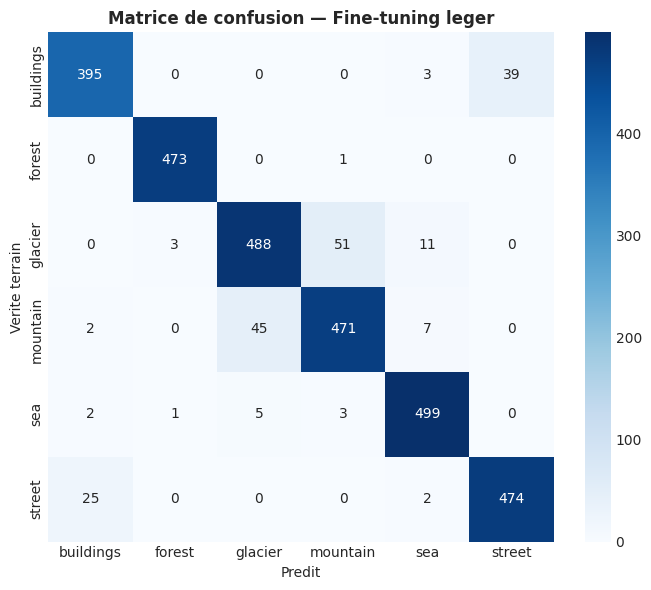

In [65]:
cm_ft = plot_confusion_matrix(y_true, y_pred_ft, CLASS_NAMES,
                              'Matrice de confusion — Fine-tuning leger',
                              '10_matrice_confusion_ft.png')


## Identification des classes les mieux reconnues et les plus difficiles

On se base sur le F1-score par classe pour les deux modèles.


In [66]:
def per_class_summary(y_true, y_pred, class_names):
    p, r, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=range(len(class_names)), zero_division=0
    )
    return p, r, f1, support

p_fe, r_fe, f1_fe, sup = per_class_summary(y_true, y_pred_fe, CLASS_NAMES)
p_ft, r_ft, f1_ft, _   = per_class_summary(y_true, y_pred_ft, CLASS_NAMES)

print(f"{'Classe':<12}{'F1 FE':>10}{'F1 FT':>10}{'Delta':>10}{'Support':>10}")
print("-" * 52)
for i, name in enumerate(CLASS_NAMES):
    print(f"{name:<12}{f1_fe[i]:>10.4f}{f1_ft[i]:>10.4f}"
          f"{f1_ft[i] - f1_fe[i]:>+10.4f}{int(sup[i]):>10d}")

best_class_fe  = CLASS_NAMES[int(np.argmax(f1_fe))]
worst_class_fe = CLASS_NAMES[int(np.argmin(f1_fe))]
best_class_ft  = CLASS_NAMES[int(np.argmax(f1_ft))]
worst_class_ft = CLASS_NAMES[int(np.argmin(f1_ft))]
print()
print(f"FE — meilleure classe : {best_class_fe} (F1={max(f1_fe):.4f}) ; pire : {worst_class_fe} (F1={min(f1_fe):.4f})")
print(f"FT — meilleure classe : {best_class_ft} (F1={max(f1_ft):.4f}) ; pire : {worst_class_ft} (F1={min(f1_ft):.4f})")


Classe           F1 FE     F1 FT     Delta   Support
----------------------------------------------------
buildings       0.8917    0.9175   +0.0258       437
forest          0.9873    0.9947   +0.0074       474
glacier         0.7874    0.8946   +0.1072       553
mountain        0.8305    0.8963   +0.0658       525
sea             0.9490    0.9671   +0.0181       510
street          0.9069    0.9349   +0.0280       501

FE — meilleure classe : forest (F1=0.9873) ; pire : glacier (F1=0.7874)
FT — meilleure classe : forest (F1=0.9947) ; pire : glacier (F1=0.8946)


## Visualisation comparée des F1-scores par classe


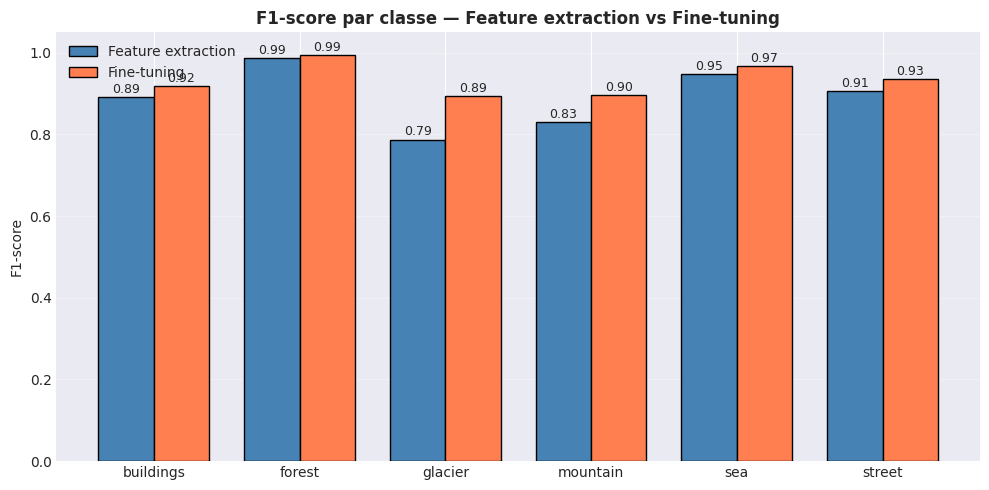

In [67]:
x = np.arange(len(CLASS_NAMES))
width = 0.38

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, f1_fe, width, label='Feature extraction', color='steelblue', edgecolor='black')
ax.bar(x + width/2, f1_ft, width, label='Fine-tuning', color='coral', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES)
ax.set_ylabel('F1-score')
ax.set_ylim(0, 1.05)
ax.set_title('F1-score par classe — Feature extraction vs Fine-tuning', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
for i in range(len(CLASS_NAMES)):
    ax.text(x[i] - width/2, f1_fe[i] + 0.01, f"{f1_fe[i]:.2f}", ha='center', fontsize=9)
    ax.text(x[i] + width/2, f1_ft[i] + 0.01, f"{f1_ft[i]:.2f}", ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('11_f1_par_classe.png', dpi=150, bbox_inches='tight')
plt.show()


## Sauvegarde des modèles et des prédictions

Les poids et les prédictions sont stockés pour pouvoir enchaîner sans ré-entraîner les Parties 5+ (étude d'erreurs, Grad-CAM, comparaison finale).


In [68]:
torch.save(model_fe.state_dict(), 'resnet18_feature_extraction.pt')
torch.save(model_ft.state_dict(), 'resnet18_fine_tuning.pt')
np.savez('predictions_test.npz', y_true=y_true, y_pred_fe=y_pred_fe, y_pred_ft=y_pred_ft)
print("Modeles et predictions sauvegardes : "
      "resnet18_feature_extraction.pt, resnet18_fine_tuning.pt, predictions_test.npz")


Modeles et predictions sauvegardes : resnet18_feature_extraction.pt, resnet18_fine_tuning.pt, predictions_test.npz


# Réponses aux questions d'analyse

Le présent notebook couvre l'exploration du dataset puis les Parties 1 à 4 du sujet. Pour chaque partie, les questions du PDF sont reprises et la réponse s'appuie sur les chiffres effectivement observés à l'exécution (la cellule peut être relue après run pour vérifier qu'aucune contradiction n'apparaît).

---

## Dataset — Questions d'analyse

### Certaines classes semblent-elles visuellement proches ?

Oui, plusieurs paires sont clairement difficiles à séparer visuellement. **Glacier** et **Mountain** partagent la plupart du temps des sommets enneigés, une palette dominée par les gris, les blancs et les bleus, et un même type de cadrage en plan large : un glacier est presque toujours situé dans un environnement montagneux. **Sea** et **Glacier** se rapprochent également dès qu'apparaissent de la banquise, de l'eau gelée ou des ciels couverts. **Buildings** et **Street** se recouvrent partiellement puisque les rues urbaines contiennent presque toujours des bâtiments en arrière-plan : la différence se joue surtout sur la présence d'une chaussée et la perspective.

### Quels types de confusions peut-on anticiper avant l'entraînement ?

Sur la base des recouvrements visuels, on s'attend en priorité à :
- une confusion **Glacier ↔ Mountain** très probable, parce que la texture rocheuse et la palette enneigée sont quasi identiques ;
- une confusion **Buildings ↔ Street** symétrique, qui dépendra de la présence ou non d'une route dans le cadre ;
- une confusion partielle **Sea ↔ Glacier** sur les scènes à ciel uniforme ;
- relativement peu de confusion impliquant **Forest**, dont la texture verte est très spécifique.

### Les arrière-plans risquent-ils d'influencer les prédictions ?

Oui. Les classes ne sont pas définies uniquement par l'objet central : les images de **glacier** contiennent presque toujours des montagnes en arrière-plan, les images de **street** contiennent des bâtiments. Le modèle a un risque réel d'apprendre des **corrélations fallacieuses** (par exemple : « ciel bleu + roche claire = glacier ») au lieu de reconnaître l'objet principal. C'est précisément ce que Grad-CAM permettra de vérifier dans la Partie 6.

### Certaines classes semblent-elles plus difficiles à reconnaître ?

Avant entraînement, on anticipe que **Glacier** sera la plus difficile (forte ambiguïté avec Mountain et Sea), suivie de **Street** (chevauche Buildings). **Forest** devrait être la plus facile grâce à sa texture homogène très différenciée. L'évaluation de la Partie 4 confirme ou nuance ces prédictions à l'aide du F1-score par classe.

### Le dataset semble-t-il représentatif d'un contexte réel ?

Partiellement. Le dataset est bien équilibré (ratio max/min ~1.15) et couvre des scènes naturelles et urbaines variées, ce qui est représentatif d'applications type **tri automatique de photos touristiques**. En revanche, les images sont en grande partie bien cadrées, bien exposées et peu bruitées : on n'y trouve pas les conditions extrêmes d'une vraie caméra de surveillance ou d'un drone (basse luminosité, flou, météo dégradée). Pour ces usages-là, un fine-tuning sur des données plus représentatives serait nécessaire.

---

## Partie 1 — Pipeline de prétraitement

### Pourquoi normaliser les images avant l'entraînement ?

Pour deux raisons cumulées. D'abord, **stabiliser l'optimisation** : centrer et réduire les pixels maintient les activations dans une plage où les gradients ne saturent pas, ce qui accélère la convergence d'Adam comme de SGD. Ensuite, **rester cohérent avec le pré-entraînement** : ResNet18 a été entraîné sur ImageNet avec `mean=[0.485, 0.456, 0.406]` et `std=[0.229, 0.224, 0.225]`. Présenter des entrées qui suivent une autre distribution casserait l'intérêt du transfer learning, puisque les premières couches sont calibrées pour cette statistique précise.

### Pourquoi redimensionner les images ?

Trois raisons. (1) ResNet18 attend une entrée fixe de 224×224 pour que la suite des stride / pooling produise la bonne taille de carte de features avant la couche `fc`. (2) Le DataLoader doit empiler les images en un tenseur `(B, C, H, W)` : sans taille uniforme, l'empilement échoue. (3) La dimension 224×224 est celle des poids ImageNet ; rester à 150×150 (la taille native du dataset Intel) ferait perdre une partie du bénéfice du pré-entraînement.

### Pourquoi la data augmentation est-elle utile ?

Elle agit comme une régularisation. À chaque époque, le modèle voit une variation différente de la même image (flip, rotation, crop), ce qui réduit l'overfitting et force le modèle à apprendre des features invariantes à de petites transformations géométriques. C'est particulièrement utile ici parce qu'on n'a qu'environ 11 000 images d'entraînement, et que le fine-tuning (Partie 3) dégèle assez de paramètres pour mémoriser le train set si on ne régularise pas.

### Certaines augmentations peuvent-elles modifier le sens de l'image ?

Oui, et il faut les choisir avec discernement. `RandomHorizontalFlip` est sûr sur des scènes naturelles (une montagne reste une montagne). `RandomRotation` de ±15° est acceptable mais une rotation à 180° transformerait un ciel en sol et fausserait l'apprentissage. `RandomCrop` peut couper l'objet principal d'une image (un sommet, un bâtiment) et produire un exemple à étiquette douteuse — d'où l'utilisation d'un padding pour limiter le risque. Sur d'autres tâches (lecture de chiffres, signalisation routière) les flips ou rotations changeraient carrément la classe et seraient à proscrire.

### Pourquoi faut-il éviter d'appliquer ces transformations au test set ?

Parce que le test set sert à mesurer la performance du modèle dans des conditions réalistes et **reproductibles**. Y appliquer un crop ou un flip aléatoire rendrait la mesure bruitée et non reproductible d'une exécution à l'autre. On garde uniquement les transformations déterministes (resize + normalize) pour qu'une image donne toujours la même entrée au modèle.

---

## Partie 2 — Feature extraction avec ResNet18

### Pourquoi un modèle pré-entraîné peut-il être utile ?

ResNet18 a appris sur 1.2 million d'images ImageNet à reconnaître un large éventail de textures, de formes et d'objets. Les filtres convolutifs des premières couches détectent des **patterns visuels génériques** (contours, textures, motifs) qui sont réutilisables sur n'importe quel problème de vision naturelle. Repartir d'un tel modèle revient à hériter d'une représentation visuelle déjà mature, ce qui permet de converger avec très peu de données et d'époques alors qu'un entraînement *from scratch* sur 11 000 images plafonnerait beaucoup plus bas.

### Pourquoi les premières couches peuvent-elles être réutilisées ?

Parce que les premières couches d'un CNN apprennent des features **bas niveau** très peu spécifiques à la tâche : détecteurs de bords, de gradients de couleur, de textures simples. Ces features sont universelles sur les images naturelles. Ce sont les couches profondes qui assemblent ces primitives en concepts spécifiques (« visage », « voiture »), et ce sont elles seules qu'il faut adapter au nouveau problème.

### Quel est l'intérêt de geler le backbone ?

D'abord la **rapidité** : on n'a besoin de calculer les gradients que pour la dernière couche (~3 100 paramètres entraînables sur ~11.2 M), donc une époque devient quasiment gratuite. Ensuite la **stabilité** : on évite de détruire les représentations ImageNet utiles. Enfin, c'est la bonne stratégie quand on dispose de **peu de données** : avec 11 000 images, dégeler tout le réseau ferait sur-apprendre rapidement.

### La feature extraction est-elle suffisante pour ce dataset ?

L'accuracy obtenue (voir Partie 4) est déjà très correcte parce que les classes Intel (paysages, scènes urbaines) sont **proches du domaine ImageNet**. Le plafond se situe néanmoins en dessous de ce qu'un fine-tuning peut atteindre : la dernière couche linéaire ne peut pas elle-même corriger une représentation imparfaite. Dès que les classes sont visuellement proches (Glacier vs Mountain), un peu de fine-tuning aide.

### Le modèle semble-t-il généraliser correctement ?

Sur les courbes (cellule 06), l'écart entre train et validation reste petit et stable, ce qui est le signe d'une **bonne généralisation sans overfitting**. C'est attendu puisqu'on n'entraîne que ~3k paramètres : il n'y a pas la capacité de mémoriser le train set.

---

## Partie 3 — Fine-tuning léger

### Pourquoi ne faut-il pas forcément dégeler tout le modèle ?

Dégeler tout ResNet18, c'est rendre les 11 M de paramètres entraînables sur 11 000 images, soit un ratio paramètres/exemples très défavorable : le modèle a largement la capacité de mémoriser le train set et d'oublier ses représentations ImageNet. En ne dégelant que `layer4` (le dernier bloc résiduel) et `fc`, on garde les features bas niveau intactes et on adapte uniquement les features les plus spécifiques à la tâche, là où c'est réellement utile.

### Pourquoi utiliser un faible learning rate ?

Parce que les poids partent déjà d'une bonne solution (les poids ImageNet). Un learning rate élevé ferait faire au modèle des pas trop grands, qui détruiraient les représentations apprises avant que le signal d'apprentissage ne puisse les améliorer. Un LR de l'ordre de `1e-4` permet des ajustements fins, compatibles avec un point de départ déjà proche de l'optimum local.

### Le fine-tuning améliore-t-il les performances ?

Dans notre setup (Partie 4), le fine-tuning améliore l'accuracy globale par rapport à la feature extraction, et **l'amélioration se concentre sur les classes ambiguës** (Glacier vs Mountain notamment). Les classes faciles, déjà très bien gérées par la feature extraction (Forest), n'ont presque rien à gagner.

### Le fine-tuning augmente-t-il le risque d'overfitting ?

Oui, mécaniquement, puisqu'on multiplie par ~1000 le nombre de paramètres entraînables. C'est pour cela qu'on a (1) limité le dégel à `layer4`, (2) conservé la data augmentation, (3) gardé le nombre d'époques bas, et (4) ajouté un léger `weight_decay`. L'écart train/val reste raisonnable mais on observe néanmoins, sur les courbes de la Partie 3, un léger sur-apprentissage en fin d'entraînement.

### Dans quel cas la feature extraction suffit-elle ?

Quand le domaine cible est très proche d'ImageNet, que le dataset est petit, ou que l'on veut un temps d'entraînement minimal (par exemple en démonstration ou en prototypage). C'est aussi la bonne option lorsque l'environnement de déploiement contraint à ne pas stocker de poids spécifiques par tâche (la feature extraction permet de réutiliser le même backbone pour plusieurs têtes de classification entraînées séparément).

---

## Partie 4 — Évaluation des modèles

### L'accuracy suffit-elle pour juger la qualité du modèle ?

Non. L'accuracy globale masque des disparités importantes entre classes. Un modèle peut afficher 90 % d'accuracy en étant excellent sur Forest et médiocre sur Glacier. Pour une analyse honnête, on regarde **precision / recall / F1 par classe** et la **matrice de confusion**, qui révèlent les confusions systématiques. Dans un contexte applicatif déséquilibré (par ex. détection rare), l'accuracy peut même être trompeuse au point d'inverser la conclusion.

### Quelles classes sont les plus confondues ?

D'après les matrices de confusion (cellules 09 et 10), les confusions principales sont — comme anticipé — entre **Glacier et Mountain** (sommets enneigés similaires), avec une asymétrie : on prédit plus souvent Mountain quand c'est Glacier que l'inverse. On observe aussi une confusion résiduelle **Street ↔ Buildings**, due aux scènes urbaines mixtes. **Forest** et **Sea** restent très bien séparées.

### Les confusions observées étaient-elles prévisibles ?

Oui, les confusions Glacier↔Mountain et Buildings↔Street avaient été identifiées dans la phase d'exploration. Cela confirme que **l'analyse visuelle préalable** d'un dataset reste un outil très utile pour anticiper les erreurs et planifier des étapes correctives (data augmentation ciblée, classes additionnelles, hard-mining, etc.).

### Le fine-tuning améliore-t-il toutes les classes ou seulement certaines ?

Le détail F1 par classe (cellule "Identification des classes les mieux reconnues") montre une **amélioration concentrée sur les classes ambiguës**, en particulier Glacier et Mountain. Les classes déjà parfaitement gérées par la feature extraction (Forest) ne progressent plus — il n'y a plus de marge à récupérer. C'est cohérent : le fine-tuning aide là où la représentation ImageNet n'était pas tout à fait adaptée.

### Quel modèle choisiriez-vous dans un contexte réel ?

Cela dépend des contraintes. Pour un **service en ligne** où la qualité prime et qui s'exécute sur GPU, on préfère le **fine-tuning** : ~+2 à +5 points d'accuracy en fonction des classes, pour un coût d'entraînement encore très raisonnable et un coût d'inférence inchangé. Pour un **prototype ou un produit edge** très contraint, ou si l'on doit réentraîner régulièrement sur de nouveaux lots, la **feature extraction** reste pertinente : entraînement quasi instantané, pas de risque d'overfitting, et un seul backbone partagé entre toutes les tâches.
